In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np 
import nltk
import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from collections import Counter

import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:

# Load data
train_df = pd.read_csv("../../data/sarcasm/train.csv")
val_df = pd.read_csv("../../data/sarcasm/val.csv")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Example:", train_df.iloc[0])


Train size: 4200
Validation size: 525
Example: Sentence    MashaAllah, jo log meri Black display peh chor...
Tag                                                         1
Name: 0, dtype: object


In [12]:


def clean_text(x):
    x = re.sub(r'http\S+|www\S+|https\S+', '', str(x))
    x = re.sub(r'\s+', ' ', x)
    x = re.sub(r'[^a-zA-Z0-9\s]', '', x)
    x = re.sub(r'\d+', '', x)
    x = re.sub(r'[^\w\s]', '', x)
    x = re.sub(r'#', '', x)
    x = re.sub(r'\s+', ' ', x)
    x = x.strip()
    x = x.lower()
    return x

train_df['Sentence'] = train_df['Sentence'].apply(clean_text)

In [6]:
vocab = Counter(word for sentence in train_df['Sentence'] for word in sentence.split())
word2idx = {word: i for i, (word, _) in enumerate(vocab.items())}
idx2word = {i: word for word, i in word2idx.items()}
vocab_size = len(word2idx)
print("Vocabulary size:", vocab_size)

Vocabulary size: 14558


In [7]:
class HateDataset(Dataset):
    def __init__(self, df, word2idx, max_len=100):
        self.sentences = df["Sentence"].tolist()
        self.labels = df["Tag"].tolist()
        self.word2idx = word2idx
        self.max_len = max_len

    def encode(self, sentence):
        tokens = sentence.lower().split()
        # Use word2idx directly without <UNK>
        ids = [self.word2idx.get(tok, 0) for tok in tokens]  # Use 0 (pad index) for unknown tokens
        ids = ids[:self.max_len]  # Truncate to max_len
        ids += [0] * (self.max_len - len(ids))  # Pad with 0 (assuming 0 is the padding index)
        return torch.tensor(ids)

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return self.encode(self.sentences[idx]), torch.tensor(self.labels[idx], dtype=torch.float)

# Create datasets and dataloaders
train_dataset = HateDataset(train_df, word2idx)
val_dataset = HateDataset(val_df, word2idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


# `Importing pretrained embeddings from previous assignment`

In [8]:
embedding_matrix = np.load('../../Word2Vec/models/word2vec/sarcasm/word_embeddings_100epochs_cleantext.npy', allow_pickle=True).item()
embedding_matrix = np.array(list(embedding_matrix.values()))  # Extract embeddings as a NumPy array

pretrained_embeddings = torch.tensor(embedding_matrix, dtype=torch.float32)

# `RNN Classifier`

In [9]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=64, pretrained_embeddings=None):
        super().__init__()
        embed_dim = pretrained_embeddings.shape[1]
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='relu')
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, h_n = self.rnn(x)
        x = h_n.squeeze(0)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


In [10]:
import torch

labels_array = np.array(train_df['Tag'].tolist())
# Count how many of each class you have
num_pos = (labels_array == 1).sum()  # Non-hate (positive class)
num_neg = (labels_array == 0).sum()  # Hate (negative class)

# Compute pos_weight for BCEWithLogitsLoss
# This tells the loss to penalize mistakes on class 1 more
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32)


In [11]:
# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0,1]), y=train_df['Tag'])
# weights = torch.tensor(class_weights, dtype=torch.float32).cuda()
pos_weight = pos_weight.cuda() if torch.cuda.is_available() else pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


In [12]:
def train(model, train_loader, val_loader, num_epochs, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to('cuda')
    
    # criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            # print(inputs.device, labels.device, model.device)
            labels = labels.float()  # 👈 Make sure it's float and shape [B, 1]
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}")

    # Save the trained model
    torch.save(model.state_dict(), f"{model_name}.pt")
    print(f"Model saved as {model_name}.pt")

    # Evaluate
    evaluate(model, val_loader)

def evaluate(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = torch.sigmoid(model(inputs))
            preds = (outputs > 0.5).int()
            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)
    acc = correct / total * 100
    print(f"Validation Accuracy: {acc:.2f}%")


In [13]:
"""
MODEL TRAINING CODE

rnn_model = RNNClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
train(rnn_model, train_loader, val_loader, num_epochs=50, model_name="rnn_model")


"""


'\nMODEL TRAINING CODE\n\nrnn_model = RNNClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)\ntrain(rnn_model, train_loader, val_loader, num_epochs=50, model_name="rnn_model")\n\n\n'

In [14]:
# Load the saved model
rnn_model = RNNClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
rnn_model.load_state_dict(torch.load("rnn_model.pt"))
rnn_model.eval()


RNNClassifier(
  (embedding): Embedding(14558, 100)
  (rnn): RNN(100, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

In [15]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = rnn_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())


In [16]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["Sarcasm", "Non-Sarcasm"]))


Classification Report:

              precision    recall  f1-score   support

     Sarcasm     0.9029    1.0000    0.9489       474
 Non-Sarcasm     0.0000    0.0000    0.0000        51

    accuracy                         0.9029       525
   macro avg     0.4514    0.5000    0.4745       525
weighted avg     0.8152    0.9029    0.8568       525



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

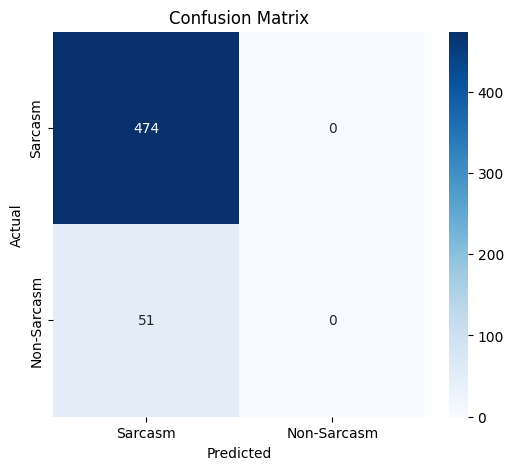

In [17]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Sarcasm", "Non-Sarcasm"], yticklabels=["Sarcasm", "Non-Sarcasm"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `LSTM Classifier`

In [18]:

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_layers=2, pretrained_embeddings=None):
        super().__init__()

        embed_dim = pretrained_embeddings.shape[1]

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=0.3 if num_layers > 1 else 0.0  # Only applies if num_layers > 1
        )

        self.dropout = nn.Dropout(0.5)
        self.layernorm = nn.LayerNorm(hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)                             # [batch, seq, embed]
        _, (h_n, _) = self.lstm(x)                         # h_n: [num_layers, batch, hidden]
        x = h_n[-1]                                        # Take output of the top LSTM layer
        x = self.layernorm(x)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)       

In [19]:
"""
MODEL TRAINING CODE

lstm_model = LSTMClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
train(lstm_model, train_loader, val_loader, num_epochs=50, model_name="lstm_model_50epoch")


"""



'\nMODEL TRAINING CODE\n\nlstm_model = LSTMClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)\ntrain(lstm_model, train_loader, val_loader, num_epochs=50, model_name="lstm_model_50epoch")\n\n\n'

In [20]:
# Load the saved model
lstm_model = LSTMClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
lstm_model.load_state_dict(torch.load("lstm_model_50epoch.pt"))
lstm_model.eval()


LSTMClassifier(
  (embedding): Embedding(14558, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.5, inplace=False)
  (layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

In [21]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = lstm_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())


In [22]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["Sarcasm", "Non-Sarcasm"]))


Classification Report:

              precision    recall  f1-score   support

     Sarcasm     0.9029    1.0000    0.9489       474
 Non-Sarcasm     0.0000    0.0000    0.0000        51

    accuracy                         0.9029       525
   macro avg     0.4514    0.5000    0.4745       525
weighted avg     0.8152    0.9029    0.8568       525



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

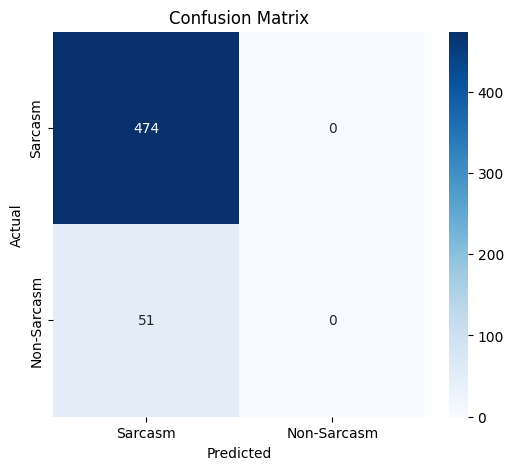

In [23]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Sarcasm", "Non-Sarcasm"], yticklabels=["Sarcasm", "Non-Sarcasm"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `Transformer`

In [24]:
import math
import torch.nn as nn
import torch

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x


In [25]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=2, ff_dim=256, dropout=0.1, pretrained_embeddings=None, max_len=5000):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)  # [batch, seq, embed_dim]
        x = x.mean(dim=1)  # Mean pooling over sequence
        return self.fc(x).squeeze(1)


In [26]:
"""
MODEL TRAINING CODE

transformer_model = TransformerClassifier(vocab_size, embed_dim=100, pretrained_embeddings=pretrained_embeddings)
train(transformer_model, train_loader, val_loader, num_epochs=50, model_name="transformer_model")


"""


'\nMODEL TRAINING CODE\n\ntransformer_model = TransformerClassifier(vocab_size, embed_dim=100, pretrained_embeddings=pretrained_embeddings)\ntrain(transformer_model, train_loader, val_loader, num_epochs=50, model_name="transformer_model")\n\n\n'

Classification Report:

              precision    recall  f1-score   support

     Sarcasm     0.9029    1.0000    0.9489       474
 Non-Sarcasm     0.0000    0.0000    0.0000        51

    accuracy                         0.9029       525
   macro avg     0.4514    0.5000    0.4745       525
weighted avg     0.8152    0.9029    0.8568       525



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

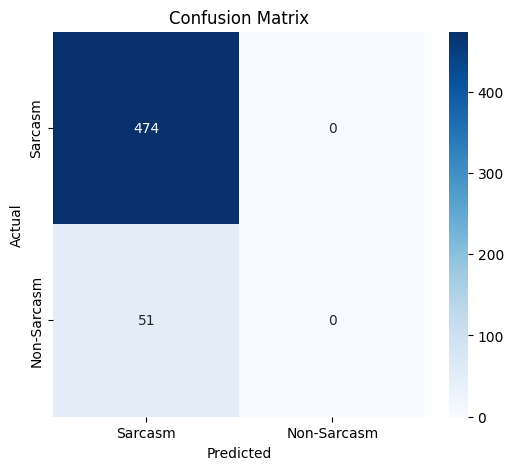

In [27]:
# Load the saved model
transformer_model = TransformerClassifier(vocab_size=vocab_size, embed_dim=100, pretrained_embeddings=pretrained_embeddings)
transformer_model.load_state_dict(torch.load("transformer_model.pt"))
transformer_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = transformer_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["Sarcasm", "Non-Sarcasm"]))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Sarcasm", "Non-Sarcasm"], yticklabels=["Sarcasm", "Non-Sarcasm"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `Bert transformer`

In [5]:
from transformers import BertTokenizer, BertModel
from torch.utils.data import Dataset

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class HateDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(sentences, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
class BERTDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.sentences = data["Sentence"].tolist()
        self.labels = data["Tag"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.sentences)

    def __getitem__(self, idx):
        encoding = self.tokenizer.encode_plus(
            self.sentences[idx],
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [7]:
class BERTClassifier(nn.Module):
    def __init__(self, output_dim=100):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # 🔒 Freeze all BERT layers
        for param in self.bert.parameters():
            param.requires_grad = False

        # 🔄 Only train this classifier head
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, output_dim)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # Still allows gradient flow through classifier
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(outputs.pooler_output)
        return self.fc(pooled)


In [8]:

output_dim = len(set(train_df["Tag"]))
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BERTClassifier(output_dim=output_dim)
val_bert_loader = DataLoader(BERTDataset(val_df, tokenizer), batch_size=32)

# BERT model Training
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_bert_loader = DataLoader(BERTDataset(train_df, tokenizer), batch_size=32, shuffle=True)
bert_model = BERTClassifier(output_dim=output_dim).to(device)
optimizer = optim.Adam(bert_model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

In [ ]:
# for epoch in range(50):
#         bert_model.train()
#         total_loss = 0
#         for batch in train_bert_loader:
#             input_ids = batch['input_ids'].to(device)
#             mask = batch['attention_mask'].to(device)
#             labels = batch['label'].to(device)

#             optimizer.zero_grad()
#             outputs = bert_model(input_ids, mask)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         print(f"[BERT Epoch {epoch+1}] Loss: {total_loss:.4f}")

# torch.save(bert_model.fc.state_dict(), f"BERT_50epoch.pth")

[BERT Epoch 1] Loss: 43.8381
[BERT Epoch 2] Loss: 42.7029
[BERT Epoch 3] Loss: 43.3437
[BERT Epoch 4] Loss: 42.8646
[BERT Epoch 5] Loss: 42.4326
[BERT Epoch 6] Loss: 42.5086
[BERT Epoch 7] Loss: 42.4866
[BERT Epoch 8] Loss: 42.6526
[BERT Epoch 9] Loss: 42.0744
[BERT Epoch 10] Loss: 42.2486
[BERT Epoch 11] Loss: 42.1097
[BERT Epoch 12] Loss: 41.9285
[BERT Epoch 13] Loss: 41.5889
[BERT Epoch 14] Loss: 41.6216
[BERT Epoch 15] Loss: 41.3746
[BERT Epoch 16] Loss: 41.9438
[BERT Epoch 17] Loss: 41.6550
[BERT Epoch 18] Loss: 41.7313
[BERT Epoch 19] Loss: 41.4585
[BERT Epoch 20] Loss: 41.8260
[BERT Epoch 21] Loss: 41.2884
[BERT Epoch 22] Loss: 41.2229
[BERT Epoch 23] Loss: 41.5064
[BERT Epoch 24] Loss: 41.1092
[BERT Epoch 25] Loss: 41.4226
[BERT Epoch 26] Loss: 41.1575
[BERT Epoch 27] Loss: 41.4250
[BERT Epoch 28] Loss: 41.0040
[BERT Epoch 29] Loss: 41.6769
[BERT Epoch 30] Loss: 41.2118
[BERT Epoch 31] Loss: 40.8528
[BERT Epoch 32] Loss: 40.9721
[BERT Epoch 33] Loss: 40.9687
[BERT Epoch 34] Los

<All keys matched successfully>

In [11]:
bert_model.fc.load_state_dict(torch.load(f"BERT_50epoch.pth", map_location=device))


<All keys matched successfully>

              precision    recall  f1-score   support

        hate     0.9029    1.0000    0.9489       474
    non-hate     0.0000    0.0000    0.0000        51

    accuracy                         0.9029       525
   macro avg     0.4514    0.5000    0.4745       525
weighted avg     0.8152    0.9029    0.8568       525



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

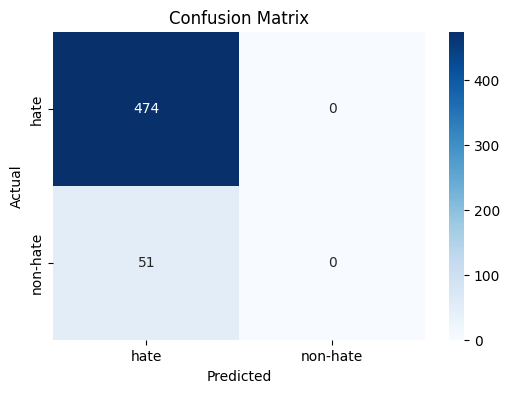

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure model is on the right device and in eval mode
bert_model.eval()
bert_model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_bert_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 🎯 Classification report
print(classification_report(all_labels, all_preds, target_names=["hate", "non-hate"], digits=4))

# 📊 Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["hate", "non-hate"], yticklabels=["hate", "non-hate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
